In [229]:
### read raw recording data
### select channels to plot MU firing rate vs map
### for Open Ephys recording
### try running PCA from raw data to extract spike waveforms

In [ ]:
### plot the receptive field and response to laser trains 
### DRG recordings

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from scipy.signal import butter, filtfilt
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [29]:
recording_path = r'N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\01_raw\2025-10-17_14-51-03\Record Node 101\experiment2\recording1'
data_dir =  os.path.join(recording_path, 'continuous\Acquisition_Board-100.Rhythm Data')
pickle_dir = r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\00_npy"
data_file = os.path.join(data_dir, 'continuous.dat').replace('\\', '/')
pickle_file = os.path.join(pickle_dir, 'acRecField_20251017_150411.pickle').replace('\\', '/')

In [30]:
data_raw = np.memmap(data_file, dtype = 'int16', mode='r')

In [83]:
nchan = 32
# sync_idx = 384
chan_select = 7 # the channel to select

sig_threshold = 6 # number of std from mean to threshold as MU

reshaped_waveform = data_raw.reshape(int(len(data_raw) / nchan), nchan)
# sync_channel = reshaped_waveform[:, sync_idx]

fs = 20000

In [127]:
# recording_path = r'C:\Users\ephys\Documents\Open Ephys\WL\2025-08-27_20-10-17\Record Node 101\experiment2\recording1'

In [84]:
i_exp_continous_path = os.path.join(recording_path, 'continuous','Acquisition_Board-100.Rhythm Data').replace('\\', '/')
i_exp_continous_file = os.path.join(i_exp_continous_path,'continuous.dat').replace('\\', '/')
i_exp_continous_sample_numbers = os.path.join(i_exp_continous_path,'sample_numbers.npy').replace('\\', '/')
i_exp_continous_timestamps = os.path.join(i_exp_continous_path,'timestamps.npy').replace('\\', '/')

i_exp_events_path = os.path.join(recording_path, 'events','Acquisition_Board-100.Rhythm Data','TTL').replace('\\', '/')
i_exp_events_full_words = os.path.join(i_exp_events_path,'full_words.npy').replace('\\', '/')
i_exp_events_sample_numbers = os.path.join(i_exp_events_path,'sample_numbers.npy').replace('\\', '/')
i_exp_events_states = os.path.join(i_exp_events_path,'states.npy').replace('\\', '/')
i_exp_events_timestamps = os.path.join(i_exp_events_path,'timestamps.npy').replace('\\', '/')

In [85]:
recording_sample_numbers = np.load(i_exp_continous_sample_numbers) ### sample of each recording
sample_numbers = np.load(i_exp_events_sample_numbers) ### sample of events
event_states = np.load(i_exp_events_states) ### code of each event


In [86]:
# for Open Ephys recording
light_start_idx = np.where(event_states == 2)[0]
trig_start_fs_light = sample_numbers[light_start_idx] # trig start sample for each light onset
trig_start_samp = trig_start_fs_light

In [87]:
# for NPx recording
# trig_on_samp = np.diff(sync_channel)>1e-10 ### find trigger start time - T/F every sample
# trig_start_samp = np.where(trig_on_samp == True)[0] # index in sampling for the onset of each trigger (each laser onset)

In [88]:
print(len(trig_start_samp))

6000


In [240]:
# print(trig_start_samp[0:200])

In [89]:
# highpass filtering
chan_wf = reshaped_waveform[:, chan_select] # raw waveform of one channel
ichan_data = chan_wf

order = 3
cutoff = 300 # hp 300Hz
b, a = butter(order, cutoff, fs=fs, btype='highpass')

ichan_filtered = filtfilt(b,a,ichan_data)

In [90]:
# thresholded MU from raw-filtered
chan_mean = np.mean(ichan_filtered)
chan_std = np.std(ichan_filtered)

chan_filtered_centered = ichan_filtered - chan_mean
wf_sig = (chan_filtered_centered < (-sig_threshold*chan_std) )*1

In [91]:
# thresholded MU from raw-filtered
wf_sig_diff = np.diff(np.concatenate((np.array([0]), wf_sig)))
wf_sig_samp = np.where(wf_sig_diff > 0) [0] # use as the MU spk sample
wf_sig_samp_adj = wf_sig_samp + recording_sample_numbers[0] # adjust samp number to samp number recorded from OE

In [92]:
print(np.sum(wf_sig_diff < 0))

534


In [93]:
print(len(wf_sig_samp_adj))

534


In [94]:
### extract the waveforms of each detected spike
samp_win_extract = [-60, 100] # extract -60 to 100 samples in time
samp_win = [-30, 70] # save -30 to 70 samples
nsamp_wf = samp_win[1] - samp_win[0]
nspk = len(wf_sig_samp_adj)
wf_sig_nspk = np.empty((0,nsamp_wf))
wf_sig_samp_adj_spk = []
# print(len(wf_sig_samp_adj))


for i in range(nspk):
    ispk_samp = wf_sig_samp[i] # extract from the raw samp numbers - not adjusted
    ispk_samp_adj = wf_sig_samp_adj[i] # adjusted samp
    ispk_samp_win = ispk_samp + samp_win_extract
    ispk_wf = chan_filtered_centered[ispk_samp_win[0]:ispk_samp_win[1]]
    # ispk_wf_min = np.min(ispk_wf)
    # ispk_wf_min_samp = np.argmin(ispk_wf)
    if ispk_wf.size >= 100:
        ispk_wf_min_samp = np.argmin(ispk_wf)
        ispk_wf_adjusted = ispk_wf[(ispk_wf_min_samp-30):(ispk_wf_min_samp+70)]
        if ispk_wf_adjusted.size == 100:
            wf_sig_nspk = np.concatenate((wf_sig_nspk, ispk_wf_adjusted.reshape(1,-1)), axis=0)
            wf_sig_samp_adj_spk.append(ispk_samp_adj)
#     plt.plot(ispk_wf_adjusted[20:50])
# plt.show()
wf_sig_samp_adj_spk = np.array(wf_sig_samp_adj_spk)

In [139]:
wf_sig_nspk.shape

(334, 100)

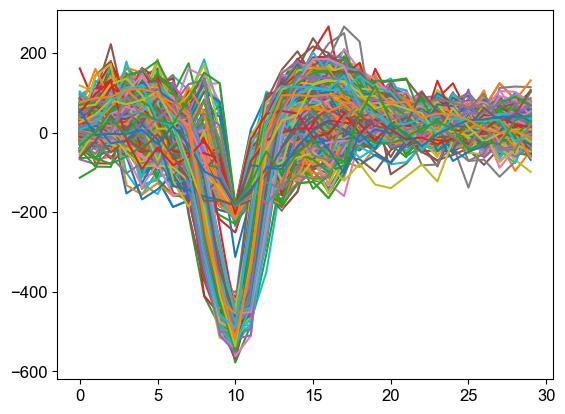

In [95]:
plt.plot(wf_sig_nspk[:,20:50].T)
plt.show()

In [96]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(wf_sig_nspk)


In [97]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(X_train)

PCA(n_components=3)

In [98]:
pca.n_components_


3

In [99]:
train_img_pca = pca.transform(X_train)

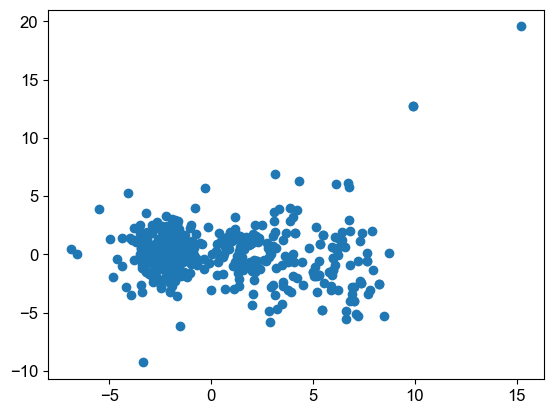

In [100]:
plt.scatter(train_img_pca[:,0],train_img_pca[:,1])

In [104]:
# spk_select = (train_img_pca[:,0] > 2.5) & (train_img_pca[:,0] < 7) 
# spk_select = (train_img_pca[:,0] > 4.3) & (train_img_pca[:,0] < 9) 
# spk_select = (train_img_pca[:,1] > - 3.5) & (train_img_pca[:,1] < 3)  & (train_img_pca[:,0] > -3.5) & (train_img_pca[:,0] < 5) 
spk_select = (train_img_pca[:,0] <0) & (train_img_pca[:,0] >-5) & (train_img_pca[:,2] < 2.1)

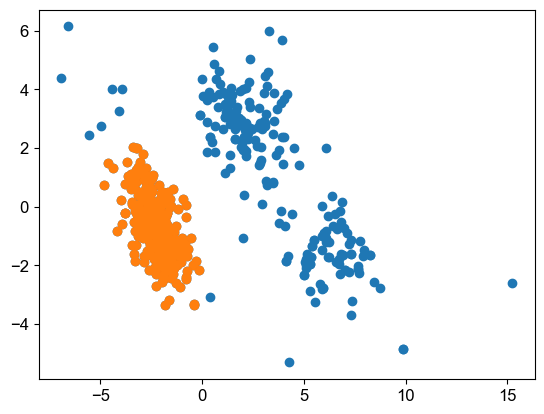

In [105]:
plt.scatter(train_img_pca[:,0],train_img_pca[:,2])
plt.scatter(train_img_pca[spk_select,0],train_img_pca[spk_select,2])

In [106]:
spk_select_samp = wf_sig_samp_adj_spk[spk_select]

In [107]:
print(len(spk_select_samp))

325


In [108]:
train_img_pca.shape

(533, 3)

In [109]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)


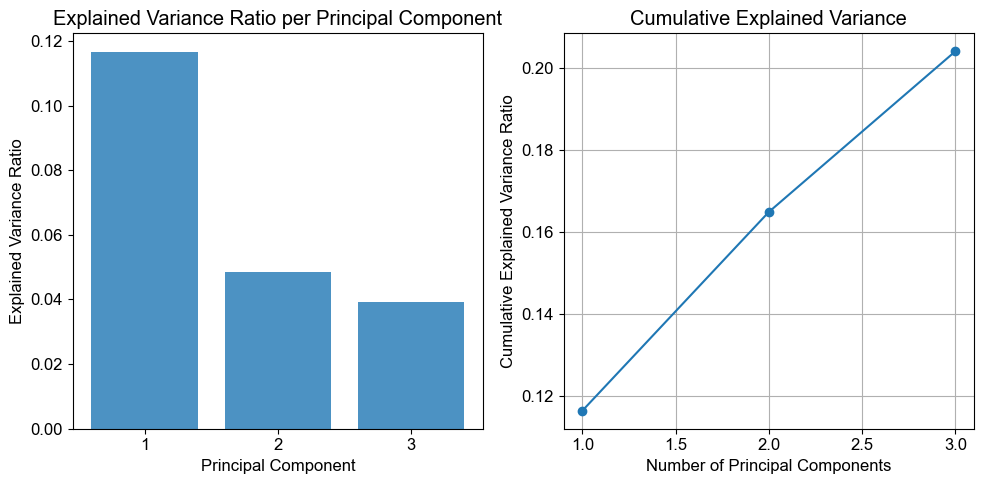

In [110]:
# 5. Plot explained variance ratio per component
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.8)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per Principal Component')
plt.xticks(range(1, len(explained_variance_ratio) + 1))

# 6. Plot cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

In [111]:
wf_sig_nspk.shape

(533, 100)

In [ ]:
# print(wf_sig_diff.shape)
# print(wf_sig_samp)
# print(len(wf_sig_samp))

In [112]:
# load pickle files
with open(pickle_file, 'rb') as handle:
    set_rf = pickle.load(handle)

In [113]:
# extract xy location in V, laser on samples
ao_xV = set_rf['ao_data'][0,:]
ao_yV = set_rf['ao_data'][1,:]
do0 = set_rf['do_data'][0,:]
V_per_mm_X = set_rf['settings']['V_per_mm_X']
V_per_mm_Y = set_rf['settings']['V_per_mm_Y']

In [114]:
### find the idx where laser is on
do_laserON = np.diff(do0 * 1)>1e-10
laserON_idx = np.where(do_laserON == True)[0]
print(len(laserON_idx))
xV_laserON = ao_xV[laserON_idx]
yV_laserON = ao_yV[laserON_idx] # the xy location when each time the laser is ON

xmm_laserON = xV_laserON/V_per_mm_X
ymm_laserON = yV_laserON/V_per_mm_Y
xV_range = np.unique(xV_laserON) # a list of all xV values (24)
yV_range = np.unique(yV_laserON) # a list of all yV values (16)

xmm_range = np.unique(xmm_laserON) # a list of all xmm values (24)
ymm_range = np.unique(ymm_laserON) # a list of all ymm values (16)
nx = len(xmm_range)
ny = len(ymm_range)
ntrial = len(laserON_idx)

print(len(xmm_range))
print(len(ymm_range))

6000
40
30


In [115]:
ntrial_xy_idx = np.zeros((ntrial, 2))
ntrial_idx = np.zeros((ntrial, 1))

for itrial in np.arange(ntrial):
    itrial_xmm = xmm_laserON[itrial]
    itrial_ymm = ymm_laserON[itrial]
    itrial_x_idx = np.where(xmm_range == itrial_xmm)[0][0]
    itrial_y_idx = np.where(ymm_range == itrial_ymm)[0][0]
    ntrial_xy_idx[itrial, 0] = itrial_x_idx
    ntrial_xy_idx[itrial, 1] = itrial_y_idx

    itrial_idx = np.ravel_multi_index((itrial_x_idx, itrial_y_idx), (nx, ny)) # 2d idx to 1d
    ntrial_idx[itrial, 0] = itrial_idx

    # print([itrial_xmm, itrial_ymm])
    # print((itrial_x_idx, itrial_y_idx))
#     plt.scatter(itrial_x_idx, itrial_y_idx)
# plt.show()

In [116]:
spk_samp_MU = spk_select_samp # using selected spk after PCA

In [76]:
spk_samp_MU = wf_sig_samp_adj # use thresholded

In [68]:
trig_start_samp

array([  912467,   914467,   916467, ..., 12906467, 12908467, 12910467],
      dtype=int64)

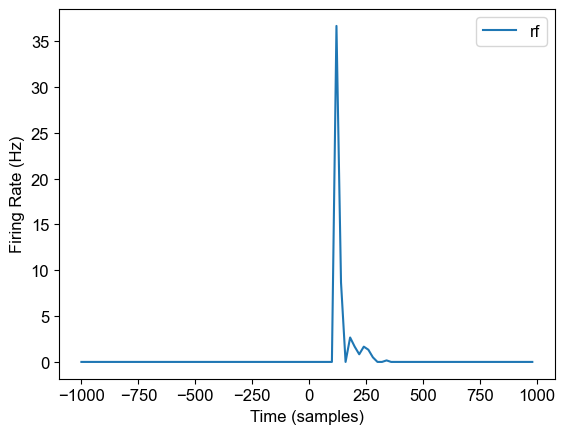

In [117]:
# extract the fr for each laser (n=3840)
ntrials_laser = ntrial
dtbin = 1/1000 # 1ms bin
trial_start = -50/1000 # start time of each trial
trial_end = 50/1000
tbin_trial = np.linspace(trial_start, trial_end, int((trial_end-trial_start)/dtbin)+1, endpoint=True)


dtbin_fs = dtbin * fs
trial_start_fs = trial_start * fs
trial_end_fs = trial_end * fs
tbin_trial_fs = np.linspace(trial_start_fs, trial_end_fs, int((trial_end_fs-trial_start_fs)/dtbin_fs)+1, endpoint=True)

# motor_trial_select = trial_order_motor >= 6 # select only >= 40mN

# for i in range(len(good_unit_ids)):
for i in range(1):
    # iunit = good_unit_ids[i]
    # iunit_spk_id = spike_clusters == iunit
    # iunit_spk_times = spike_times[iunit_spk_id]
    iunit_spk_samp = spk_samp_MU
    # iunit_spk_times_s = iunit_spk_times/fs

    iunit_spk_laser1 = []

    iunit_psth_laser1 = []


    for itrial in np.arange(0,ntrials_laser):
        itrial_trig_start = trig_start_samp[itrial] + trial_start_fs
        itrial_trig_end = trig_start_samp[itrial] + trial_end_fs
        ispk_samp_itrial = iunit_spk_samp[(iunit_spk_samp>itrial_trig_start)&(iunit_spk_samp<itrial_trig_end)] - trig_start_samp[itrial]
        iunit_spk_laser1.append(ispk_samp_itrial)
        iunit_spk_count, tbins = np.histogram(ispk_samp_itrial, bins=tbin_trial_fs, density=False)
        iunit_psth = iunit_spk_count / dtbin
        iunit_psth_laser1.append(iunit_psth)


    iunit_psth_laser1_array = np.asarray(iunit_psth_laser1)
    
    iunit_psth_laser1_mean = np.mean(iunit_psth_laser1_array, axis = 0)

    plt.plot(tbin_trial_fs[:-1], iunit_psth_laser1_mean, label = 'rf')

    # plt.vlines(1, ymin = 0,  linestyles= ':', linewidth = 0.5)
    # plt.vlines(1.5,ymin = 0, linestyles= ':', linewidth = 0.5)
    # plt.xlim(0.5,2.0)
    plt.ylabel('Firing Rate (Hz)')
    plt.xlabel('Time (samples)')
    plt.legend()
    # plt.title(str(i)+' Unit'+str(iunit))
    
    # figname_iunit = os.path.join(save_fig_path, 'unit'+ str(iunit) + '.png')
    # plt.savefig(figname_iunit)

    plt.show()

(6000,)
(40, 30)


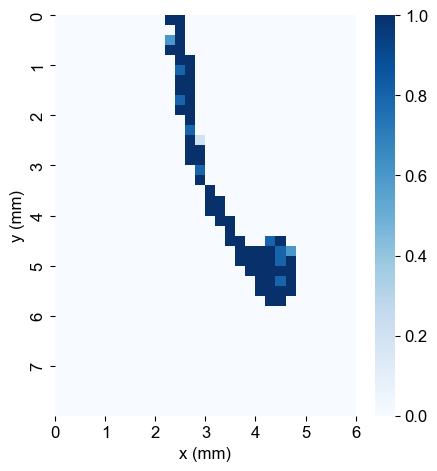

In [118]:
twin_laser = np.arange(50,65)

for i in range(1):

    iunit_psth_laser_rf_array = iunit_psth_laser1_array

    iunit_fr_xy = np.zeros((nx, ny))

    iunit_fr_bytrial = np.mean(iunit_psth_laser_rf_array[:, twin_laser], axis=1)
    print(iunit_fr_bytrial.shape)
    # print(iunit_fr_bytrial.shape)
    iunit_fr_cond = np.zeros((nx*ny,1))

    for icond_idx in range(nx*ny): # for each x&y combination condition
        # print(icond_idx)
        icond_trial_idx = np.where(ntrial_idx == icond_idx)[0]
        # print(icond_trial_idx)
        # print(iunit_fr_bytrial[icond_trial_idx])
        icond_fr = np.mean(iunit_fr_bytrial[icond_trial_idx])
        # print(icond_fr)
        iunit_fr_cond[icond_idx,0] = icond_fr
        # print(icond_trial_idx)
    iunit_fr_xy = iunit_fr_cond.reshape(nx,ny)
    print(iunit_fr_xy.shape)
    iunit_spk_prob_xy = iunit_fr_xy * dtbin * len(twin_laser)

    fig, ax = plt.subplots(figsize = (5,5.2))
    ax = sns.heatmap(iunit_spk_prob_xy, vmin=0, vmax=1, cmap = 'Blues')
    ax.invert_xaxis()
    # plt.title(str(i)+' Unit'+str(iunit))

    ax.set_xticks([0,5,10,15,20,25,30])
    ax.set_xticklabels([6,5,4,3,2,1,0])

    ax.set_yticks([0,5,10,15,20,25,30,35])
    ax.set_yticklabels([0,1,2,3,4,5,6,7])
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')

    plt.show()


In [119]:
x_select_idx =35
y_select_idx =14
print([xmm_range[x_select_idx],ymm_range[y_select_idx]])

[22.999999999999975, -43.69999999999996]


In [120]:
spk_latency = []
for itrial in np.arange(0,ntrials_laser):
    itrial_spk_samp = iunit_spk_laser1[itrial]
    itrial_spk_samp_light = itrial_spk_samp[itrial_spk_samp>0]
    if itrial_spk_samp_light.size > 0:
        itrial_spk_latency_ms = itrial_spk_samp_light[0]/fs*1000
        if (itrial_spk_latency_ms > 0) & (itrial_spk_latency_ms < 15):
            spk_latency.append(itrial_spk_latency_ms)

In [121]:
np.unique(spk_latency)

array([ 6.15,  6.2 ,  6.25,  6.3 ,  6.35,  6.4 ,  6.45,  6.5 ,  6.55,
        6.6 ,  6.65,  6.7 ,  6.75,  6.8 ,  6.85,  6.9 ,  6.95,  7.  ,
        7.05,  7.1 ,  7.15,  7.2 ,  7.25,  7.3 ,  7.4 ,  7.45,  7.5 ,
        7.55,  7.6 ,  7.65,  7.7 ,  7.8 ,  7.85,  9.  ,  9.05,  9.1 ,
        9.15,  9.2 ,  9.3 ,  9.35,  9.4 ,  9.55,  9.6 ,  9.65,  9.9 ,
       10.  , 10.05, 10.1 , 10.2 , 10.25, 10.5 , 10.75, 10.9 , 10.95,
       11.05, 11.35, 11.55, 11.95, 12.05, 12.1 , 12.2 , 12.25, 12.65,
       12.7 , 12.85, 12.9 , 13.1 , 13.25, 13.3 , 13.35, 13.55, 13.85,
       13.9 , 14.  , 14.85])

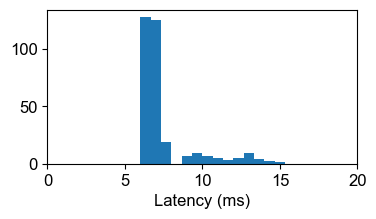

In [147]:
fig, ax = plt.subplots(figsize = (4,2))

ax.hist(spk_latency,bins=30, range=(0, 20))
ax.set_xlabel('Latency (ms)')
ax.set_xlim(0,20)
plt.show()

In [123]:
print(np.mean(spk_latency))
print(np.median(spk_latency))

7.471759259259257
6.75


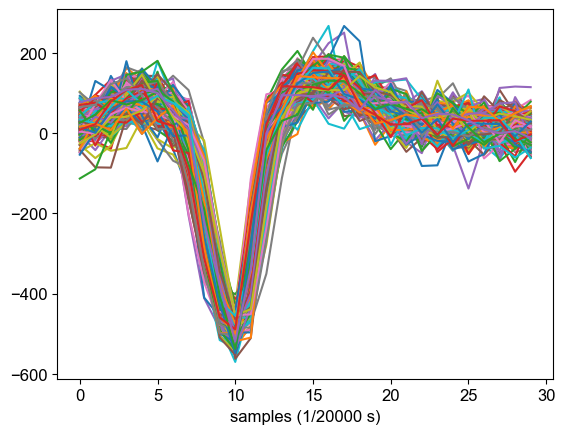

In [124]:
plt.plot(wf_sig_nspk[spk_select,20:50].T)
plt.xlabel('samples (1/20000 s)')
plt.show()

In [ ]:
##### OPTOTAG FILE

In [255]:
# files for optotag
recording_path_optotag = r'N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\01_raw\2025-10-17_14-51-03\Record Node 101\experiment4\recording1'
data_dir_optotag =  os.path.join(recording_path_optotag, 'continuous\Acquisition_Board-100.Rhythm Data')
pickle_dir = r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\00_npy"
data_file_optotag = os.path.join(data_dir_optotag, 'continuous.dat').replace('\\', '/')
pickle_file_optotag = os.path.join(pickle_dir, 'optotag_20251017_153752.pickle').replace('\\', '/')### plot response to optotag

In [256]:
data_raw = np.memmap(data_file_optotag, dtype = 'int16', mode='r')

In [257]:
nchan = 32
# sync_idx = 384
chan_select = 7 # the channel to select

sig_threshold = 6 # number of std from mean to threshold as MU

reshaped_waveform = data_raw.reshape(int(len(data_raw) / nchan), nchan)
# sync_channel = reshaped_waveform[:, sync_idx]

fs = 20000

In [258]:
i_exp_continous_path = os.path.join(recording_path_optotag, 'continuous','Acquisition_Board-100.Rhythm Data').replace('\\', '/')
i_exp_continous_file = os.path.join(i_exp_continous_path,'continuous.dat').replace('\\', '/')
i_exp_continous_sample_numbers = os.path.join(i_exp_continous_path,'sample_numbers.npy').replace('\\', '/')
i_exp_continous_timestamps = os.path.join(i_exp_continous_path,'timestamps.npy').replace('\\', '/')

i_exp_events_path = os.path.join(recording_path_optotag, 'events','Acquisition_Board-100.Rhythm Data','TTL').replace('\\', '/')
i_exp_events_full_words = os.path.join(i_exp_events_path,'full_words.npy').replace('\\', '/')
i_exp_events_sample_numbers = os.path.join(i_exp_events_path,'sample_numbers.npy').replace('\\', '/')
i_exp_events_states = os.path.join(i_exp_events_path,'states.npy').replace('\\', '/')
i_exp_events_timestamps = os.path.join(i_exp_events_path,'timestamps.npy').replace('\\', '/')

In [259]:
recording_sample_numbers = np.load(i_exp_continous_sample_numbers) ### sample of each recording
sample_numbers = np.load(i_exp_events_sample_numbers) ### sample of events
event_states = np.load(i_exp_events_states) ### code of each event


In [260]:
# sample number for the start of each light pulse
light_start_idx = np.where(event_states == 2)[0]
trig_start_fs_light = sample_numbers[light_start_idx] # trig start sample for each light onset
trig_start_samp = trig_start_fs_light

In [261]:
# sample number for the start of each trial
trial_start_idx = np.where(event_states == 1)[0]
trials_LED1 = 10
trials_LED1_idx = trial_start_idx[0:10]

trig_start_fs_LED1 = sample_numbers[trials_LED1_idx]
# trig_start_fs_LED1_adj = trig_start_fs_LED1

In [262]:
trig_start_fs_LED1

array([ 184343,  584343,  984343, 1384343, 1784343, 2184343, 2584343,
       2984343, 3384343, 3784343], dtype=int64)

In [88]:
# for NPx recording
# trig_on_samp = np.diff(sync_channel)>1e-10 ### find trigger start time - T/F every sample
# trig_start_samp = np.where(trig_on_samp == True)[0] # index in sampling for the onset of each trigger (each laser onset)

In [263]:
print(len(trig_start_samp))

1540


In [264]:
# highpass filtering
chan_wf = reshaped_waveform[:, chan_select] # raw waveform of one channel
ichan_data = chan_wf

order = 3
cutoff = 300 # hp 300Hz
b, a = butter(order, cutoff, fs=fs, btype='highpass')

ichan_filtered = filtfilt(b,a,ichan_data)

In [265]:
# thresholded MU from raw-filtered
chan_mean = np.mean(ichan_filtered)
chan_std = np.std(ichan_filtered)

chan_filtered_centered = ichan_filtered - chan_mean
wf_sig = (chan_filtered_centered < (-sig_threshold*chan_std) )*1

In [266]:
# thresholded MU from raw-filtered
wf_sig_diff = np.diff(np.concatenate((np.array([0]), wf_sig)))
wf_sig_samp = np.where(wf_sig_diff > 0) [0] # use as the MU spk sample
wf_sig_samp_adj = wf_sig_samp + recording_sample_numbers[0] # adjust samp number to samp number recorded from OE

In [267]:
print(np.sum(wf_sig_diff < 0))
print(len(wf_sig_samp_adj))

1480
1480


In [268]:
spktime_samp = wf_sig_samp_adj
spktime_s = spktime_samp / fs
trig_start_time_LED1 = trig_start_fs_LED1 /fs

In [ ]:
# spktime_s_file = r"N:\Liu_Wanyi\TrkC\DRG\spktime_optotag_BPV4.npy"
# trig_start_time_file = r"N:\Liu_Wanyi\TrkC\DRG\trig_start_time_optotag_BPV4.npy"
# np.save(spktime_s_file, spktime_s)
# np.save(trig_start_time_file, trig_start_time_LED1)

In [269]:
### extract the waveforms of each detected spike
samp_win_extract = [-90, 100] # extract -60 to 100 samples in time
samp_win = [-30, 70] # save -30 to 70 samples
nsamp_wf = samp_win[1] - samp_win[0]
nspk = len(wf_sig_samp_adj)
wf_sig_nspk = np.empty((0,nsamp_wf))
wf_sig_samp_adj_spk = []
# print(len(wf_sig_samp_adj))


for i in range(nspk):
    ispk_samp = wf_sig_samp[i] # extract from the raw samp numbers - not adjusted
    ispk_samp_adj = wf_sig_samp_adj[i] # adjusted samp
    ispk_samp_win = ispk_samp + samp_win_extract
    ispk_wf = chan_filtered_centered[ispk_samp_win[0]:ispk_samp_win[1]]
    # ispk_wf_min = np.min(ispk_wf)
    # ispk_wf_min_samp = np.argmin(ispk_wf)
    if ispk_wf.size >= 100:
        ispk_wf_min_samp = np.argmin(ispk_wf)
        ispk_wf_adjusted = ispk_wf[int(ispk_wf_min_samp-30):int(ispk_wf_min_samp+70)]
        if ispk_wf_adjusted.size == 100:
            wf_sig_nspk = np.concatenate((wf_sig_nspk, ispk_wf_adjusted.reshape(1,-1)), axis=0)
            wf_sig_samp_adj_spk.append(ispk_samp_adj)
        else:
            print(i)
            print(ispk_samp_adj)
#     plt.plot(ispk_wf_adjusted[20:50])
# plt.show()
wf_sig_samp_adj_spk = np.array(wf_sig_samp_adj_spk)

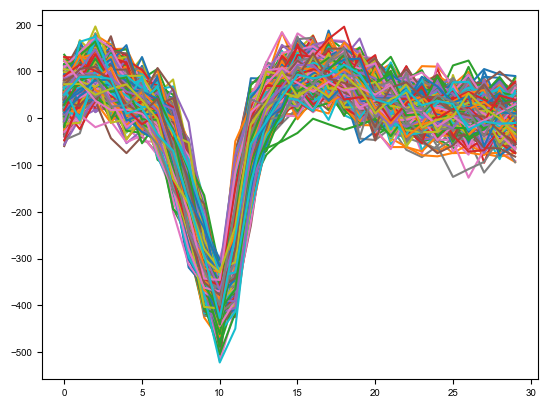

In [270]:
plt.plot(wf_sig_nspk[:,20:50].T)
plt.show()

In [271]:
# spktime_samp = wf_sig_samp_adj[spk_select]
spktime_samp = wf_sig_samp_adj

spktime_s = spktime_samp / fs
trig_start_time_LED1 = trig_start_fs_LED1 /fs

In [ ]:
# LED time for optotagging (from ChR2 optotagging so it is called LED)
ntrials = 10
### time of LED onset in each trial
LED_freq = [2,5,10,20,40]
LED_start_time = np.array([])
for ifreq in range(len(LED_freq)):
    ifreq_LED = LED_freq[ifreq]
    ifreq_time = np.linspace(ifreq*2, ifreq*2 + 2, ifreq_LED * 2, endpoint=False)
    LED_start_time = np.concatenate((LED_start_time, ifreq_time))
    # print(LED_start_time)

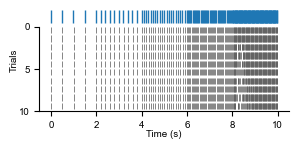

In [ ]:
ntrials = 10     
y_trial = 0  
spk_time_trials = []

fig, ax = plt.subplots(figsize = (3,1.5))
for itrial in np.arange(0,ntrials):
    itrial_trig_start = trig_start_time_LED1[itrial]
    itrial_trig_end = itrial_trig_start + 12.5
    ispk_time_itrial = spktime_s[(spktime_s>itrial_trig_start)&(spktime_s<itrial_trig_end)] - itrial_trig_start
    ax.vlines(ispk_time_itrial - 1, y_trial, y_trial+0.75, color = "#555555", linewidth= 0.5)

    # ax.scatter(ispk_time_itrial,np.repeat(y_trial, len(ispk_time_itrial)), marker = '|', color = 'black', alpha = 0.7)
    # plt.vlines(np.arange(1,11) ,0, ntrials, linestyles= ':', linewidth = 0.5, alpha = 0.3)
    y_trial += 1

    spk_time_trials.append(ispk_time_itrial-1)

ax.vlines(LED_start_time, ymin = -2, ymax = -0.5, linewidth=1, zorder = 101)

    
ax.set_xlim(-0.5,10.5)
ax.set_ylim(-2,10)
ax.set_xlabel('Time (s)',labelpad=0)
ax.set_ylabel('Trial',labelpad=0)

ax.set_yticks([0,5,10])
ax.set_yticklabels([0,5,10])

ax.spines['left'].set_bounds((0, 10))
ax.spines['bottom'].set_zorder(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()

# plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_optotag.pdf",dpi=600,bbox_inches='tight',transparent=True)
plt.show()



In [144]:
spk_time_all = np.concatenate(spk_time_trials)

In [145]:
print(sum(spk_time_all<2))
print(sum(spk_time_all<4) - sum(spk_time_all<2))
print(sum(spk_time_all<6) - sum(spk_time_all<4))
print(sum(spk_time_all<8) - sum(spk_time_all<6))
print(sum(spk_time_all<10) - sum(spk_time_all<8))

40
100
200
400
740


In [ ]:
##### plotting spikes for sync_trace0

In [292]:
# files for sync_trace0
recording_path_sync = r'N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\01_raw\2025-10-17_14-51-03\Record Node 101\experiment5\recording1'
data_dir_sync =  os.path.join(recording_path_sync, 'continuous\Acquisition_Board-100.Rhythm Data')
pickle_dir = r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\00_npy"
data_file_sync = os.path.join(data_dir_sync, 'continuous.dat').replace('\\', '/')
pickle_file_sync = os.path.join(pickle_dir, 'physioLaser_sync_20251017_154354.pickle').replace('\\', '/')### plot response to optotag

In [293]:
data_raw = np.memmap(data_file_sync, dtype = 'int16', mode='r')

In [294]:
nchan = 32
# sync_idx = 384
chan_select = 7 # the channel to select

sig_threshold = 7 # number of std from mean to threshold as MU

reshaped_waveform = data_raw.reshape(int(len(data_raw) / nchan), nchan)
# sync_channel = reshaped_waveform[:, sync_idx]

fs = 20000

In [295]:
i_exp_continous_path = os.path.join(recording_path_sync, 'continuous','Acquisition_Board-100.Rhythm Data').replace('\\', '/')
i_exp_continous_file = os.path.join(i_exp_continous_path,'continuous.dat').replace('\\', '/')
i_exp_continous_sample_numbers = os.path.join(i_exp_continous_path,'sample_numbers.npy').replace('\\', '/')
i_exp_continous_timestamps = os.path.join(i_exp_continous_path,'timestamps.npy').replace('\\', '/')

i_exp_events_path = os.path.join(recording_path_sync, 'events','Acquisition_Board-100.Rhythm Data','TTL').replace('\\', '/')
i_exp_events_full_words = os.path.join(i_exp_events_path,'full_words.npy').replace('\\', '/')
i_exp_events_sample_numbers = os.path.join(i_exp_events_path,'sample_numbers.npy').replace('\\', '/')
i_exp_events_states = os.path.join(i_exp_events_path,'states.npy').replace('\\', '/')
i_exp_events_timestamps = os.path.join(i_exp_events_path,'timestamps.npy').replace('\\', '/')

In [296]:
recording_sample_numbers = np.load(i_exp_continous_sample_numbers) ### sample of each recording
sample_numbers = np.load(i_exp_events_sample_numbers) ### sample of events
event_states = np.load(i_exp_events_states) ### code of each event


In [297]:
# sample number for the start of each light pulse
light_start_idx = np.where(event_states == 2)[0]
trig_start_fs_light = sample_numbers[light_start_idx] # trig start sample for each light onset
trig_start_samp = trig_start_fs_light

In [298]:
len(trig_start_samp)

300

In [299]:
# sample number for the start of each trial
trial_start_idx = np.where(event_states == 1)[0]
ntrials_LED1 = len(trial_start_idx)
trials_LED1_idx = trial_start_idx[0:ntrials_LED1]

trig_start_fs_LED1 = sample_numbers[trials_LED1_idx]
# trig_start_fs_LED1_adj = trig_start_fs_LED1

In [300]:
len(trig_start_fs_LED1)

30

In [301]:
print(len(trig_start_samp))

300


In [302]:
# highpass filtering
chan_wf = reshaped_waveform[:, chan_select] # raw waveform of one channel
ichan_data = chan_wf

order = 3
cutoff = 300 # hp 300Hz
b, a = butter(order, cutoff, fs=fs, btype='highpass')

ichan_filtered = filtfilt(b,a,ichan_data)

In [303]:
# thresholded MU from raw-filtered
chan_mean = np.mean(ichan_filtered)
chan_std = np.std(ichan_filtered)

chan_filtered_centered = ichan_filtered - chan_mean
wf_sig = (chan_filtered_centered < (-sig_threshold*chan_std) )*1

In [304]:
# thresholded MU from raw-filtered
wf_sig_diff = np.diff(np.concatenate((np.array([0]), wf_sig)))
wf_sig_samp = np.where(wf_sig_diff > 0) [0] # use as the MU spk sample
wf_sig_samp_adj = wf_sig_samp + recording_sample_numbers[0] # adjust samp number to samp number recorded from OE

In [305]:
print(np.sum(wf_sig_diff < 0))
print(len(wf_sig_samp_adj))

300
300


In [306]:
spktime_samp = wf_sig_samp_adj
spktime_s = spktime_samp / fs
trig_start_time_LED1 = trig_start_fs_LED1 /fs

In [ ]:
# spktime_s_file = r"N:\Liu_Wanyi\TrkC\DRG\spktime_sync0_BPV4.npy"
# trig_start_time_file = r"N:\Liu_Wanyi\TrkC\DRG\trig_start_time_sync0_BPV4.npy"
# np.save(spktime_s_file, spktime_s)
# np.save(trig_start_time_file, trig_start_time_LED1)

In [313]:
# load time (in samples) for sync trace0
laser_samp_dir = r'N:\Liu_Wanyi\code_TrkC\sync_samp'
sync0_samp_file = 'sync_samp_set0.npy'

laser_samp_sync0_file = os.path.join(laser_samp_dir, sync0_samp_file)
laser_samp_sync0 = np.load(laser_samp_sync0_file)

laser_time_sync_trace0 = laser_samp_sync0[0] / 30000 # for NPx sampling rate=30000

In [314]:
laser_time_sync_trace0

array([0.   , 0.03 , 0.055, 0.078, 0.165, 0.198, 0.231, 0.317, 0.366,
       0.445])

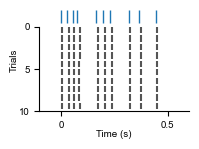

In [ ]:
ntrials = 30     
y_trial = 0  

fig, ax = plt.subplots(figsize = (2,1.5))
for itrial in np.arange(0,ntrials):
    itrial_trig_start = trig_start_time_LED1[itrial]
    itrial_trig_end = itrial_trig_start + 1.5
    ispk_time_itrial = spktime_s[(spktime_s>itrial_trig_start)&(spktime_s<itrial_trig_end)] - itrial_trig_start
    ax.vlines(ispk_time_itrial - 1, y_trial, y_trial+0.75, color="#555555")

    # ax.scatter(ispk_time_itrial,np.repeat(y_trial, len(ispk_time_itrial)), marker = '|', color = 'black', alpha = 0.7)
    # plt.vlines(np.arange(1,11) ,0, ntrials, linestyles= ':', linewidth = 0.5, alpha = 0.3)
    y_trial += 1
    
    
ax.vlines(laser_time_sync_trace0, ymin = -2, ymax = -0.5, linewidth=1, zorder = 101)
    
ax.set_xlim(-0.1,0.6)
ax.set_ylim(-2,10)
ax.set_xlabel('Time (s)',labelpad=0)
ax.set_ylabel('Trial',labelpad=0)

ax.set_yticks([0,5,10])
ax.set_yticklabels([0,5,10])

ax.set_xticks([0,0.5])
ax.set_xticklabels([0,0.5])

ax.spines['left'].set_bounds((0, 10))
ax.spines['bottom'].set_zorder(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
# plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_synctrace0.pdf",dpi=600,bbox_inches='tight',transparent=True)
plt.show()


In [ ]:
# 40 Hz RF
# 30 x 20 locations, each 10 laser pulses (at 40 Hz)
# 1 s per trial (600 trials total)
# recording session ~ 10 min

In [2]:
recording_path = r'N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\01_raw\2025-10-17_14-51-03\Record Node 101\experiment3\recording1'
data_dir =  os.path.join(recording_path, 'continuous\Acquisition_Board-100.Rhythm Data')
pickle_dir = r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\00_npy"
data_file = os.path.join(data_dir, 'continuous.dat').replace('\\', '/')
pickle_file = os.path.join(pickle_dir, 'acRecField_20251017_153454.pickle').replace('\\', '/')

In [3]:
data_raw = np.memmap(data_file, dtype = 'int16', mode='r')

In [4]:
nchan = 32
# sync_idx = 384
chan_select = 7 # the channel to select

sig_threshold = 10 # number of std from mean to threshold as MU

reshaped_waveform = data_raw.reshape(int(len(data_raw) / nchan), nchan)
# sync_channel = reshaped_waveform[:, sync_idx]

fs = 20000

In [5]:
i_exp_continous_path = os.path.join(recording_path, 'continuous','Acquisition_Board-100.Rhythm Data').replace('\\', '/')
i_exp_continous_file = os.path.join(i_exp_continous_path,'continuous.dat').replace('\\', '/')
i_exp_continous_sample_numbers = os.path.join(i_exp_continous_path,'sample_numbers.npy').replace('\\', '/')
i_exp_continous_timestamps = os.path.join(i_exp_continous_path,'timestamps.npy').replace('\\', '/')

i_exp_events_path = os.path.join(recording_path, 'events','Acquisition_Board-100.Rhythm Data','TTL').replace('\\', '/')
i_exp_events_full_words = os.path.join(i_exp_events_path,'full_words.npy').replace('\\', '/')
i_exp_events_sample_numbers = os.path.join(i_exp_events_path,'sample_numbers.npy').replace('\\', '/')
i_exp_events_states = os.path.join(i_exp_events_path,'states.npy').replace('\\', '/')
i_exp_events_timestamps = os.path.join(i_exp_events_path,'timestamps.npy').replace('\\', '/')

In [6]:
recording_sample_numbers = np.load(i_exp_continous_sample_numbers) ### sample of each recording
sample_numbers = np.load(i_exp_events_sample_numbers) ### sample of events
event_states = np.load(i_exp_events_states) ### code of each event


In [7]:
# for Open Ephys recording
light_start_idx = np.where(event_states == 2)[0] 
trig_start_fs_light = sample_numbers[light_start_idx] # trig start sample for each light onset
# trig_start_samp = trig_start_fs_light
trig_start_samp = trig_start_fs_light[::10] # 10 light per trial/location



In [8]:
print(len(trig_start_samp))

600


In [9]:
print(np.diff(sample_numbers[np.where(event_states == 2)[0]])[0:20])
print(sample_numbers[np.where(event_states == 1)[0]])

[  500   500   500   500   500   500   500   500   500 15500   500   500
   500   500   500   500   500   500   500 15500]
[  233284   233784   234284 ... 12216784 12217284 12217784]


In [10]:
# highpass filtering
chan_wf = reshaped_waveform[:, chan_select] # raw waveform of one channel
ichan_data = chan_wf

order = 3
cutoff = 300 # hp 300Hz
b, a = butter(order, cutoff, fs=fs, btype='highpass')

ichan_filtered = filtfilt(b,a,ichan_data)

In [11]:
# thresholded MU from raw-filtered
chan_mean = np.mean(ichan_filtered)
chan_std = np.std(ichan_filtered)

chan_filtered_centered = ichan_filtered - chan_mean
wf_sig = (chan_filtered_centered < (-sig_threshold*chan_std) )*1

In [12]:
# thresholded MU from raw-filtered
wf_sig_diff = np.diff(np.concatenate((np.array([0]), wf_sig)))
wf_sig_samp = np.where(wf_sig_diff > 0) [0] # use as the MU spk sample
wf_sig_samp_adj = wf_sig_samp + recording_sample_numbers[0] # adjust samp number to samp number recorded from OE

In [13]:
print(np.sum(wf_sig_diff < 0))

113


In [14]:
### extract the waveforms of each detected spike
samp_win_extract = [-60, 100] # extract -60 to 100 samples in time
samp_win = [-30, 70] # save -30 to 70 samples
nsamp_wf = samp_win[1] - samp_win[0]
nspk = len(wf_sig_samp_adj)
wf_sig_nspk = np.empty((0,nsamp_wf))
wf_sig_samp_adj_spk = []
# print(len(wf_sig_samp_adj))


for i in range(nspk):
    ispk_samp = wf_sig_samp[i] # extract from the raw samp numbers - not adjusted
    ispk_samp_adj = wf_sig_samp_adj[i] # adjusted samp
    ispk_samp_win = ispk_samp + samp_win_extract
    ispk_wf = chan_filtered_centered[ispk_samp_win[0]:ispk_samp_win[1]]
    # ispk_wf_min = np.min(ispk_wf)
    # ispk_wf_min_samp = np.argmin(ispk_wf)
    if ispk_wf.size >= 100:
        ispk_wf_min_samp = np.argmin(ispk_wf)
        ispk_wf_adjusted = ispk_wf[(ispk_wf_min_samp-30):(ispk_wf_min_samp+70)]
        if ispk_wf_adjusted.size == 100:
            wf_sig_nspk = np.concatenate((wf_sig_nspk, ispk_wf_adjusted.reshape(1,-1)), axis=0)
            wf_sig_samp_adj_spk.append(ispk_samp_adj)
#     plt.plot(ispk_wf_adjusted[20:50])
# plt.show()
wf_sig_samp_adj_spk = np.array(wf_sig_samp_adj_spk)

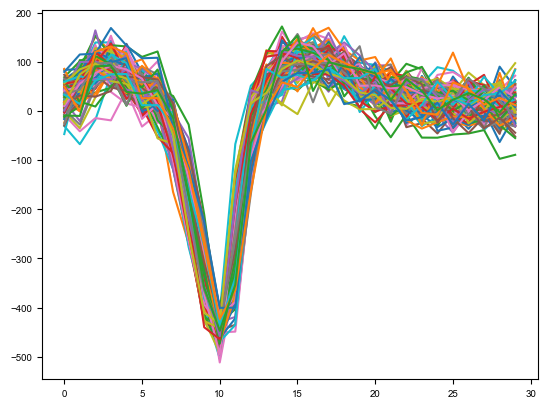

In [15]:
plt.plot(wf_sig_nspk[:,20:50].T)
plt.show()

In [16]:
# load pickle files
with open(pickle_file, 'rb') as handle:
    set_rf = pickle.load(handle)

In [17]:
# extract xy location in V, laser on samples
ao_xV = set_rf['ao_data'][0,:]
ao_yV = set_rf['ao_data'][1,:]
do0 = set_rf['do_data'][0,:]
V_per_mm_X = set_rf['settings']['V_per_mm_X']
V_per_mm_Y = set_rf['settings']['V_per_mm_Y']

In [18]:
### find the idx where laser is on
do_laserON = np.diff(do0 * 1)>1e-10
laserON_idx = np.where(do_laserON == True)[0]
trialON_idx = laserON_idx[::10]
print(len(laserON_idx))
print(len(trialON_idx))
xV_laserON = ao_xV[laserON_idx]
yV_laserON = ao_yV[laserON_idx] # the xy location when each time the laser is ON

xmm_laserON = xV_laserON/V_per_mm_X
ymm_laserON = yV_laserON/V_per_mm_Y
xV_range = np.unique(xV_laserON) # a list of all xV values (24)
yV_range = np.unique(yV_laserON) # a list of all yV values (16)

xmm_range = np.unique(xmm_laserON) # a list of all xmm values (24)
ymm_range = np.unique(ymm_laserON) # a list of all ymm values (16)
nx = len(xmm_range)
ny = len(ymm_range)
ntrial = len(trialON_idx)

print(len(xmm_range))
print(len(ymm_range))

6000
600
30
20


In [19]:
ntrial_xy_idx = np.zeros((ntrial, 2))
ntrial_idx = np.zeros((ntrial, 1))

xmm_trialON = xmm_laserON[::10]
ymm_trialON = ymm_laserON[::10]
for itrial in np.arange(ntrial):
    itrial_xmm = xmm_trialON[itrial]
    itrial_ymm = ymm_trialON[itrial]
    itrial_x_idx = np.where(xmm_range == itrial_xmm)[0][0]
    itrial_y_idx = np.where(ymm_range == itrial_ymm)[0][0]
    ntrial_xy_idx[itrial, 0] = itrial_x_idx
    ntrial_xy_idx[itrial, 1] = itrial_y_idx

    itrial_idx = np.ravel_multi_index((itrial_x_idx, itrial_y_idx), (nx, ny)) # 2d idx to 1d
    ntrial_idx[itrial, 0] = itrial_idx

    # print([itrial_xmm, itrial_ymm])
    # print((itrial_x_idx, itrial_y_idx))
#     plt.scatter(itrial_x_idx, itrial_y_idx)
# plt.show()

In [20]:
spk_samp_MU = wf_sig_samp_adj # use thresholded

In [152]:
len(trig_start_samp)

600

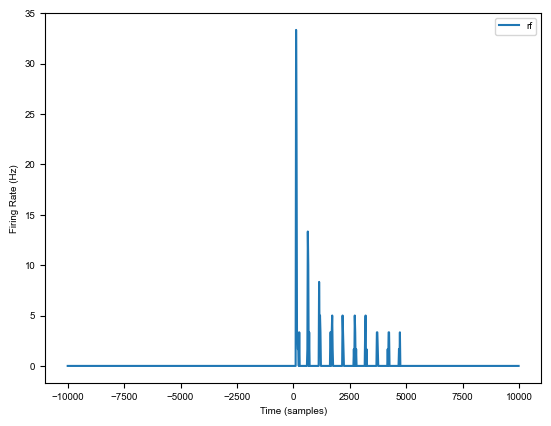

In [21]:
# extract the fr for each laser (n=3840)
ntrials_laser = ntrial
dtbin = 1/1000 # 1ms bin
trial_start = -500/1000 # start time of each trial
trial_end = 500/1000
tbin_trial = np.linspace(trial_start, trial_end, int((trial_end-trial_start)/dtbin)+1, endpoint=True)


dtbin_fs = dtbin * fs
trial_start_fs = trial_start * fs
trial_end_fs = trial_end * fs
tbin_trial_fs = np.linspace(trial_start_fs, trial_end_fs, int((trial_end_fs-trial_start_fs)/dtbin_fs)+1, endpoint=True)

# motor_trial_select = trial_order_motor >= 6 # select only >= 40mN

# for i in range(len(good_unit_ids)):
for i in range(1):
    # iunit = good_unit_ids[i]
    # iunit_spk_id = spike_clusters == iunit
    # iunit_spk_times = spike_times[iunit_spk_id]
    iunit_spk_samp = spk_samp_MU
    # iunit_spk_times_s = iunit_spk_times/fs

    iunit_spk_laser1 = []

    iunit_psth_laser1 = []


    for itrial in np.arange(0,ntrials_laser):
        itrial_trig_start = trig_start_samp[itrial] + trial_start_fs
        itrial_trig_end = trig_start_samp[itrial] + trial_end_fs
        ispk_samp_itrial = iunit_spk_samp[(iunit_spk_samp>itrial_trig_start)&(iunit_spk_samp<itrial_trig_end)] - trig_start_samp[itrial]
        iunit_spk_laser1.append(ispk_samp_itrial)
        iunit_spk_count, tbins = np.histogram(ispk_samp_itrial, bins=tbin_trial_fs, density=False)
        iunit_psth = iunit_spk_count / dtbin
        iunit_psth_laser1.append(iunit_psth)


    iunit_psth_laser1_array = np.asarray(iunit_psth_laser1)
    
    iunit_psth_laser1_mean = np.mean(iunit_psth_laser1_array, axis = 0)

    plt.plot(tbin_trial_fs[:-1], iunit_psth_laser1_mean, label = 'rf')

    # plt.vlines(1, ymin = 0,  linestyles= ':', linewidth = 0.5)
    # plt.vlines(1.5,ymin = 0, linestyles= ':', linewidth = 0.5)
    # plt.xlim(0.5,2.0)
    plt.ylabel('Firing Rate (Hz)')
    plt.xlabel('Time (samples)')
    plt.legend()
    # plt.title(str(i)+' Unit'+str(iunit))
    
    # figname_iunit = os.path.join(save_fig_path, 'unit'+ str(iunit) + '.png')
    # plt.savefig(figname_iunit)

    plt.show()

(600,)
(30, 20)


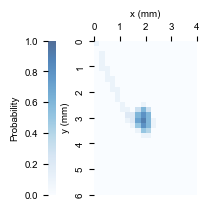

In [22]:
twin_laser = np.arange(500,1000)

for i in range(1):

    iunit_psth_laser_rf_array = iunit_psth_laser1_array

    iunit_fr_xy = np.zeros((nx, ny))

    iunit_fr_bytrial = np.mean(iunit_psth_laser_rf_array[:, twin_laser], axis=1)
    print(iunit_fr_bytrial.shape)
    # print(iunit_fr_bytrial.shape)
    iunit_fr_cond = np.zeros((nx*ny,1))

    for icond_idx in range(nx*ny): # for each x&y combination condition
        # print(icond_idx)
        icond_trial_idx = np.where(ntrial_idx == icond_idx)[0]
        # print(icond_trial_idx)
        # print(iunit_fr_bytrial[icond_trial_idx])
        icond_fr = np.mean(iunit_fr_bytrial[icond_trial_idx])
        # print(icond_fr)
        iunit_fr_cond[icond_idx,0] = icond_fr
        # print(icond_trial_idx)
    iunit_fr_xy = iunit_fr_cond.reshape(nx,ny)
    print(iunit_fr_xy.shape)
    iunit_spk_count_xy = iunit_fr_xy * dtbin * len(twin_laser)

    fig, ax = plt.subplots(figsize = (5,2))
    ax = sns.heatmap(iunit_spk_count_xy/10, vmin=0, vmax=1, cmap = 'Blues',alpha = 0.7, cbar_kws={'label': 'Probability', 'location':'left'})
    # ax = sns.heatmap(iunit_spk_count_xy, cmap = 'Blues')

    ax.invert_xaxis()
    # plt.title(str(i)+' Unit'+str(iunit))
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')
    ax.xaxis.set_label_position('top') # Move the *axis title* to the top
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

    ax.set_xticks([0,5,10,15,20])
    ax.set_xticklabels([4,3,2,1,0])

    ax.set_yticks([0,5,10,15,20,25,30])
    ax.set_yticklabels([0,1,2,3,4,5,6])
    
    # plt.tight_layout()
    # plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_RF_labeled.pdf",dpi=600,bbox_inches='tight',transparent=True)
    # plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_RF_labeled2.png",dpi=600,bbox_inches='tight',transparent=True)

    plt.show()


(600,)
(30, 20)


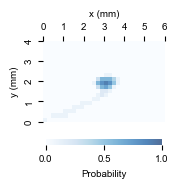

In [23]:
# rotate xy axis
twin_laser = np.arange(500,1000)

for i in range(1):

    iunit_psth_laser_rf_array = iunit_psth_laser1_array

    iunit_fr_xy = np.zeros((nx, ny))

    iunit_fr_bytrial = np.mean(iunit_psth_laser_rf_array[:, twin_laser], axis=1)
    print(iunit_fr_bytrial.shape)
    # print(iunit_fr_bytrial.shape)
    iunit_fr_cond = np.zeros((nx*ny,1))

    for icond_idx in range(nx*ny): # for each x&y combination condition
        # print(icond_idx)
        icond_trial_idx = np.where(ntrial_idx == icond_idx)[0]
        # print(icond_trial_idx)
        # print(iunit_fr_bytrial[icond_trial_idx])
        icond_fr = np.mean(iunit_fr_bytrial[icond_trial_idx])
        # print(icond_fr)
        iunit_fr_cond[icond_idx,0] = icond_fr
        # print(icond_trial_idx)
    iunit_fr_xy = iunit_fr_cond.reshape(nx,ny)
    print(iunit_fr_xy.shape)
    iunit_spk_count_xy = iunit_fr_xy * dtbin * len(twin_laser)

    fig, ax = plt.subplots(figsize = (3,1.5))
    ax = sns.heatmap(iunit_spk_count_xy.T/10, vmin=0, vmax=1, cmap = 'Blues',alpha = 0.7, cbar_kws={'label': 'Probability', 'location':'bottom',"shrink": 0.5})
    # ax = sns.heatmap(iunit_spk_count_xy, cmap = 'Blues')

    # ax.invert_yaxis()
    # plt.title(str(i)+' Unit'+str(iunit))
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')
    ax.xaxis.set_label_position('top') # Move the *axis title* to the top
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

    ax.set_yticks([0,5,10,15,20])
    ax.set_yticklabels([4,3,2,1,0])

    ax.set_xticks([0,5,10,15,20,25,30])
    ax.set_xticklabels([0,1,2,3,4,5,6])
    
    # plt.tight_layout()
    plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_RF_T_labeled.pdf",dpi=600,bbox_inches='tight',transparent=True)
    # plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_RF_T_labeled2.png",dpi=600,bbox_inches='tight',transparent=True)

    plt.show()


In [ ]:
# rf_spk_count = iunit_spk_count_xy
# psth_laser = iunit_psth_laser1_array

# rf_spk_count_file = r"N:\Liu_Wanyi\TrkC\DRG\RF_spkcount_40Hz.npy"

# np.save(rf_spk_count_file, rf_spk_count)


[18.8 19.  19. ]
[-43.4 -43.4 -43.6]
[273]
[283]
[417]


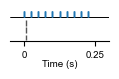

In [ ]:
# plot the raster of 3 at axon fiber
laser_pulse_samp = np.linspace(0, 0.25*fs, int(40*0.25), endpoint=False)

x_idx1 = np.array([4,5,5])
y_idx1 = np.array([18,18,17])
print(xmm_range[x_idx1])
print(ymm_range[y_idx1])

iunit_spk_idx1 = []
y_trial = 0

dtbin = 1/1000 # 1ms bin
trial_start = -500/1000 # start time of each trial
trial_end = 500/1000
tbin_trial = np.linspace(trial_start, trial_end, int((trial_end-trial_start)/dtbin)+1, endpoint=True)

dtbin_fs = dtbin * fs
trial_start_fs = trial_start * fs
trial_end_fs = trial_end * fs
tbin_trial_fs = np.linspace(trial_start_fs, trial_end_fs, int((trial_end_fs-trial_start_fs)/dtbin_fs)+1, endpoint=True)

fig, ax = plt.subplots(figsize = (1.2,0.8))
for i in range(3): # for each x&y combination condition
    # print(icond_idx)

    itrial_idx = np.ravel_multi_index((x_idx1[i], y_idx1[i]), (nx, ny))

    icond_trial_idx = np.where(ntrial_idx == itrial_idx)[0]
    print(icond_trial_idx)

    iunit_spk_samp = spk_samp_MU

    itrial_trig_start = trig_start_samp[icond_trial_idx] + trial_start_fs
    itrial_trig_end = trig_start_samp[icond_trial_idx] + trial_end_fs
    ispk_samp_itrial = iunit_spk_samp[(iunit_spk_samp>itrial_trig_start)&(iunit_spk_samp<itrial_trig_end)] - trig_start_samp[icond_trial_idx]
    
    iunit_spk_idx1.append(ispk_samp_itrial)

    ax.vlines(ispk_samp_itrial, y_trial, y_trial+0.75, color = '#555555', linewidth=1)
    y_trial += 1
    ax.hlines(-0.5, xmin=-1000, xmax=6000,  color = 'black', linewidth=0.5)

    ax.vlines(laser_pulse_samp, ymin = -1.25, ymax = -0.5, linewidth=1, zorder = 101)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.spines['left'].set_visible(False)

    ax.set_xlim(-1000,6000)
    ax.set_xticks([0,5000])
    ax.set_xticks([0,5000])
    ax.set_xticklabels([0,0.25])
    ax.set_xlabel('Time (s)',labelpad=0)
    ax.spines['left'].set_bounds((0, 3))
    ax.invert_yaxis()
    plt.tight_layout()
    # plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_RF_raster_fiber.pdf",dpi=600,bbox_inches='tight',transparent=True)


[21.  21.2 21. ]
[-45.  -45.  -44.8]
[190]
[281]
[36]


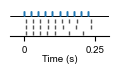

In [ ]:
# plot the raster of 3 at axon terminal
laser_pulse_samp = np.linspace(0, 0.25*fs, int(40*0.25), endpoint=False)

x_idx1 = np.array([15,16,15])
y_idx1 = np.array([10,10,11])
print(xmm_range[x_idx1])
print(ymm_range[y_idx1])

iunit_spk_idx1 = []
y_trial = 0

dtbin = 1/1000 # 1ms bin
trial_start = -500/1000 # start time of each trial
trial_end = 500/1000
tbin_trial = np.linspace(trial_start, trial_end, int((trial_end-trial_start)/dtbin)+1, endpoint=True)


dtbin_fs = dtbin * fs
trial_start_fs = trial_start * fs
trial_end_fs = trial_end * fs
tbin_trial_fs = np.linspace(trial_start_fs, trial_end_fs, int((trial_end_fs-trial_start_fs)/dtbin_fs)+1, endpoint=True)


fig, ax = plt.subplots(figsize = (1.2,0.75))
for i in range(3): # for each x&y combination condition
    # print(icond_idx)

    itrial_idx = np.ravel_multi_index((x_idx1[i], y_idx1[i]), (nx, ny))

    icond_trial_idx = np.where(ntrial_idx == itrial_idx)[0]
    print(icond_trial_idx)

    iunit_spk_samp = spk_samp_MU

    itrial_trig_start = trig_start_samp[icond_trial_idx] + trial_start_fs
    itrial_trig_end = trig_start_samp[icond_trial_idx] + trial_end_fs
    ispk_samp_itrial = iunit_spk_samp[(iunit_spk_samp>itrial_trig_start)&(iunit_spk_samp<itrial_trig_end)] - trig_start_samp[icond_trial_idx]
    
    iunit_spk_idx1.append(ispk_samp_itrial)

    ax.vlines(ispk_samp_itrial, y_trial, y_trial+0.75, color = '#555555', linewidth=1)
    y_trial += 1
    ax.hlines(-0.5, xmin=-1000, xmax=6000,  color = 'black', linewidth=0.5)

    ax.vlines(laser_pulse_samp, ymin = -1.25, ymax = -0.5, linewidth=1, zorder = 101)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.spines['left'].set_visible(False)

    ax.set_xlim(-1000,6000)
    ax.set_xticks([0,5000])
    ax.set_xticks([0,5000])
    ax.set_xticklabels([0,0.25])
    ax.set_xlabel('Time (s)',labelpad=0)
    ax.spines['left'].set_bounds((0, 3))
    ax.invert_yaxis()
    plt.tight_layout()
    # plt.savefig(r"N:\Liu_Wanyi\processing_data\251017_BPV4_DRG\BPV4_DRG_RF_raster_terminal.pdf",dpi=600,bbox_inches='tight',transparent=True)

    # plt.show()
    

In [193]:
6/1000*20000

120.0